# Who Is the Most Famous Person in History?

Monte Carlo estimation: sample random people from all of human history, then ask an LLM whether each person would have heard of various famous candidates.

"Famous" here means: **what fraction of all humans ever born would have known of this person's existence?**

In [1]:
import numpy as np
import dill
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

from person import sample_person
from llm_utils import get_client, make_langchain_messages, CostTracker, extract_json

## 1. Sample random people

Pickle the results so we don't have to re-sample each time.

In [2]:
N = 100000
PICKLE_FILE = f'famous_person_sample_{N}.pkl'

import os
if os.path.exists(PICKLE_FILE):
    print(f'Loading {N} people from {PICKLE_FILE}...')
    with open(PICKLE_FILE, 'rb') as f:
        people = dill.load(f)
else:
    print(f'Sampling {N} people...')
    people = [sample_person(light=True) for _ in tqdm(range(N), desc='Sampling')]
    with open(PICKLE_FILE, 'wb') as f:
        dill.dump(people, f)
    print(f'Saved to {PICKLE_FILE}')

Loading 100000 people from famous_person_sample_100000.pkl...


In [3]:
# Quick look at who we sampled
for i, p in enumerate(people[:10]):
    if p.era == 'Paleolithic':
        print(f"{p.birth_year_str:>12s} \t {str(p.age_at_death):>5s} \t {p.sex} \t {p.region}")
    else:
        loc = p.location
        print(f"{p.birth_year_str:>12s} \t {str(p.age_at_death):>5s} \t {p.sex} \t {loc.subregion}, {loc.country}")

     1185 BC 	    64 	 F 	 Guerrero, Mexico
     1108 AD 	     0 	 M 	 Guizhou, China
     1982 AD 	 alive 	 M 	 Nariño, Colombia
     1266 BC 	    38 	 M 	 Borsod-Abauj-Zemplen, Hungary
      983 AD 	     5 	 M 	 Tamil Nādu, India
     1311 AD 	     0 	 F 	 England, United Kingdom
     1828 AD 	    21 	 F 	 Henan, China
      268 BC 	     0 	 F 	 Andhra Pradesh, India
      859 AD 	    25 	 F 	 Connacht, Ireland
     1942 AD 	     1 	 M 	 Asyūţ, Egypt


## 2. Filter and bin

Remove people who obviously couldn't know any famous person on our list, then bin similar people together so we only need one LLM call per bin.

In [4]:
from export import get_continent
from collections import defaultdict
import random

AMERICAS = {'North America', 'South America'}

def passes_filter(person):
    """Return True if this person could plausibly know of a famous historical figure."""
    if person.birth_year < -500 or person.birth_year > 2020:
        return False
    if person.age_at_death != "alive" and person.age_at_death < 5:
        return False
    country = person.location.country if person.era == 'Holocene' else None
    region = person.region if person.era == 'Paleolithic' else None
    continent = get_continent(country, region)
    if continent in AMERICAS and person.birth_year < 1500:
        return False
    return True

def get_death_year(person):
    """Return the year this person died (or 2026 if alive)."""
    if person.age_at_death == "alive":
        return 2026
    return person.birth_year + person.age_at_death

def get_era(person):
    by = person.birth_year
    if by < 0:        return "pre-0"
    elif by < 600:    return "0-600"
    elif by < 1500:   return "600-1500"
    elif by < 1800:   return "1500-1800"
    elif by < 1900:   return "1800-1900"
    elif by < 1950:   return "1900-1950"
    elif by < 1980:   return "1950-1980"
    else:             return "1980+"

def get_fine_bin(person):
    """Fine bin: (era, country)."""
    country = person.location.country if person.era == 'Holocene' else person.region
    return (get_era(person), country)

def get_continent_for_person(person):
    country = person.location.country if person.era == 'Holocene' else None
    region = person.region if person.era == 'Paleolithic' else None
    return get_continent(country, region)

# ── Filter ──
filtered = [p for p in people if passes_filter(p)]
print(f"Passed filter: {len(filtered)}/{len(people)} ({100*len(filtered)/len(people):.0f}%)")

Passed filter: 45808/100000 (46%)


In [24]:
# ── Maximum possible fame by start year ──
# What fraction of filtered people died after year X?
# This gives the ceiling for anyone who became famous in year X.
n_total = len(people)
n_filtered = len(filtered)

death_years = np.array([get_death_year(p) for p in filtered])

# Also compute for ALL people (not just filtered) to get the fraction of all humans
all_death_years = np.array([get_death_year(p) for p in people])

checkpoints = [-500,1,500,1000,1200,1400,1600,1800,1850,1900,1950,2000,2020,2025]

print(f"Maximum possible fame fraction by start year")
print(f"(fraction of all {n_total:,} people who pass filter AND died after year X)\n")
print(f"  {'Year':>6s}   {'Filtered alive':>15s}   {'% of all people':>15s}")
print(f"  {'-'*6}   {'-'*15}   {'-'*15}")
for year in checkpoints:
    n_alive = np.sum(death_years >= year)
    frac_all = n_alive / n_total
    print(f"  {year:>6d}   {n_alive:>10,d}/{n_filtered:<5,d}   {frac_all:>14.1%}")

Maximum possible fame fraction by start year
(fraction of all 100,000 people who pass filter AND died after year X)

    Year    Filtered alive   % of all people
  ------   ---------------   ---------------
    -500       45,808/45,808            45.8%
       1       43,032/45,808            43.0%
     500       39,251/45,808            39.3%
    1000       34,834/45,808            34.8%
    1200       32,548/45,808            32.5%
    1400       29,796/45,808            29.8%
    1600       26,681/45,808            26.7%
    1800       22,554/45,808            22.6%
    1850       20,930/45,808            20.9%
    1900       18,908/45,808            18.9%
    1950       16,686/45,808            16.7%
    2000       14,004/45,808            14.0%
    2020       12,480/45,808            12.5%
    2025       12,016/45,808            12.0%


In [8]:
# Within-bin std dev estimates by era (from 1k GPT-5.2 run)
# Used ONLY for Neyman allocation, not for SE calculation.
# Three levels: country < continent < era (increasing heterogeneity)
ERA_SIGMA = {
    "pre-0": 0.010, "0-600": 0.051, "600-1500": 0.085,
    "1500-1800": 0.086, "1800-1900": 0.168, "1900-1950": 0.190,
    "1950-1980": 0.104, "1980+": 0.140,
}
ERA_SIGMA_CONTINENT = {k: v * 1.5 for k, v in ERA_SIGMA.items()}  # continent ≈ 1.5× country
ERA_SIGMA_MERGED = {
    "pre-0": 0.100, "0-600": 0.227, "600-1500": 0.194,
    "1500-1800": 0.204, "1800-1900": 0.256, "1900-1950": 0.250,
    "1950-1980": 0.180, "1980+": 0.249,
}

# ── Fine bins (era × country) ──
fine_bins = defaultdict(list)
for i, p in enumerate(filtered):
    fine_bins[get_fine_bin(p)].append(i)
print(f"Fine bins: {len(fine_bins)}")

# ── Step 1: Initial Neyman allocation on fine bins ──
BUDGET = 800  # total LLM calls
MIN_DRAWS = 3

fine_keys = list(fine_bins.keys())
fine_sizes = np.array([len(fine_bins[k]) for k in fine_keys])
fine_sigmas = np.array([ERA_SIGMA[k[0]] for k in fine_keys])

neyman_raw = fine_sizes * fine_sigmas
n_alloc_init = BUDGET * neyman_raw / neyman_raw.sum()

# ── Step 2: Three-level merge ──
# Level 1: country bins with enough allocation stay
final_bins = {}
continent_overflow = defaultdict(list)  # (era, continent) -> list of filtered indices

for i, key in enumerate(fine_keys):
    if n_alloc_init[i] >= MIN_DRAWS:
        final_bins[key] = fine_bins[key]
    else:
        # Find continent for this bin's members
        era = key[0]
        # All members of a (era, country) bin share the same continent
        sample_person = filtered[fine_bins[key][0]]
        continent = get_continent_for_person(sample_person)
        continent_overflow[(era, continent)].extend(fine_bins[key])

# Level 2: continent bins with enough allocation stay
era_overflow = defaultdict(list)  # era -> list of filtered indices

for cont_key, members in continent_overflow.items():
    era = cont_key[0]
    # Check if this continent bin would get enough draws
    sigma = ERA_SIGMA_CONTINENT[era]
    neyman_share = len(members) * sigma
    # We'll compute the actual allocation after assembling all final bins,
    # but estimate here: would this bin get >= MIN_DRAWS?
    estimated_alloc = BUDGET * neyman_share / neyman_raw.sum()
    if estimated_alloc >= MIN_DRAWS and len(members) >= MIN_DRAWS:
        final_bins[cont_key] = members
    else:
        era_overflow[era].extend(members)

# Level 3: remaining small bins merge by era
for era, members in era_overflow.items():
    if members:
        final_bins[(era, "_merged")] = members

# ── Step 3: Redo Neyman allocation on final bins with appropriate σ ──
final_keys = list(final_bins.keys())
final_sizes = np.array([len(final_bins[k]) for k in final_keys])

def get_bin_sigma(key):
    era = key[0]
    level = key[1]
    if level == "_merged":
        return ERA_SIGMA_MERGED[era]
    elif level in ('Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania'):
        return ERA_SIGMA_CONTINENT[era]
    else:  # country-level
        return ERA_SIGMA[era]

final_sigmas = np.array([get_bin_sigma(k) for k in final_keys])

neyman_final = final_sizes * final_sigmas
n_alloc_final = BUDGET * neyman_final / neyman_final.sum()
final_n_draws = np.array([max(MIN_DRAWS, round(n)) for n in n_alloc_final])

# Trim if over budget
while final_n_draws.sum() > BUDGET * 1.1:
    idx = np.argmax(final_n_draws)
    if final_n_draws[idx] > MIN_DRAWS:
        final_n_draws[idx] -= 1
    else:
        break

# Sample representatives from each bin
random.seed(42)
to_query = []

for b, key in enumerate(final_keys):
    members = final_bins[key]
    n_draws = min(final_n_draws[b], len(members))
    final_n_draws[b] = n_draws
    chosen = random.sample(members, n_draws)
    for idx in chosen:
        to_query.append((filtered[idx], b))

print(f"\nFinal bins: {len(final_bins)} (from {len(fine_bins)} fine bins)")
print(f"Budget: {BUDGET}, actual LLM calls: {len(to_query)}")
print(f"Draws per bin: min={final_n_draws.min()}, median={int(np.median(final_n_draws))}, max={final_n_draws.max()}")

# Show bins by level
n_country = sum(1 for k in final_keys if k[1] not in ('_merged', 'Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania'))
n_continent = sum(1 for k in final_keys if k[1] in ('Africa', 'Asia', 'Europe', 'North America', 'South America', 'Oceania'))
n_merged = sum(1 for k in final_keys if k[1] == '_merged')
print(f"  Country-level: {n_country}, Continent-level: {n_continent}, Era-merged: {n_merged}")

print(f"\n{'Bin':<40s} {'Pop':>6s} {'σ':>6s} {'Draws':>6s}")
print("-" * 61)
for b, key in enumerate(final_keys):
    label = f"{key[0]}, {key[1]}"
    print(f"{label:<40s} {final_sizes[b]:>6d} {final_sigmas[b]:>6.3f} {final_n_draws[b]:>6d}")
print(f"\n{'TOTAL':<40s} {final_sizes.sum():>6d} {'':>6s} {final_n_draws.sum():>6d}")

Fine bins: 1100

Final bins: 74 (from 1100 fine bins)
Budget: 800, actual LLM calls: 819
Draws per bin: min=3, median=7, max=40
  Country-level: 35, Continent-level: 31, Era-merged: 8

Bin                                         Pop      σ  Draws
-------------------------------------------------------------
600-1500, India                            3542  0.085     40
1800-1900, China                           1545  0.168     35
1500-1800, China                           1494  0.086     17
1950-1980, China                           1048  0.104     15
1900-1950, United States                    180  0.190      5
1980+, India                               1520  0.140     28
600-1500, China                            1926  0.085     22
1900-1950, China                           1029  0.190     26
1980+, Nigeria                              292  0.140      5
1980+, China                               1231  0.140     23
1950-1980, India                            708  0.104     10
0-600, In

## 3. Candidates and LLM query

In [9]:
CANDIDATES = [
    "Jesus of Nazareth",
    "The Virgin Mary",
    "Mary Magdalene",
    "Saint Paul",
    "Saint Peter",
    "Judas Iscariot",
    "Muhammad",
    "Ali ibn Abi Talib",
    "Aisha",
    "Fatimah",
    "Buddha",
    "Confucius",
    "Mencius",
    "Alexander the Great",
    "Julius Caesar",
    "Cleopatra",
    "Genghis Khan",
    "Qin Shi Huang",
    "Gandhi",
    "Napoleon Bonaparte",
    "Adolf Hitler",
    "Aristotle",
    "Christopher Columbus",
    "Queen Victoria",
    "Queen Elizabeth II",
    "Donald Trump",
    "Barack Obama",
    "Albert Einstein",
    "Charles Darwin",
    "Isaac Newton",
    "Karl Marx",
    "Stalin",
    "Mao Zedong",
    "George Washington",
    "Mother Teresa",
    "Joan of Arc",
    "Indira Gandhi",
    "William Shakespeare",
    "Leonardo da Vinci",
    "Michael Jackson",
    "Taylor Swift",
    "Cristiano Ronaldo",
    "Lionel Messi",
    "Nelson Mandela",
    "Princess Diana",
    "Marie Curie",
]

# Conservative (early) estimates of when each candidate's fame could plausibly
# have started spreading.
FAME_START = {
    "Buddha":                -450,
    "Confucius":             -450,
    "Mencius":               -300,
    "Alexander the Great":   -330,
    "Aristotle":             -340,
    "Qin Shi Huang":        -220,
    "Julius Caesar":          -50,
    "Cleopatra":              -50,
    "Jesus of Nazareth":       30,
    "The Virgin Mary":         30,
    "Mary Magdalene":          30,
    "Judas Iscariot":          30,
    "Saint Paul":              50,
    "Saint Peter":             50,
    "Muhammad":               620,
    "Ali ibn Abi Talib":      640,
    "Aisha":                  640,
    "Fatimah":                640,
    "Genghis Khan":          1200,
    "Joan of Arc":           1430,
    "Christopher Columbus":  1492,
    "Leonardo da Vinci":     1490,
    "William Shakespeare":   1590,
    "Isaac Newton":          1687,
    "George Washington":     1775,
    "Napoleon Bonaparte":    1799,
    "Queen Victoria":        1837,
    "Karl Marx":             1848,
    "Charles Darwin":        1859,
    "Marie Curie":           1903,
    "Albert Einstein":       1905,
    "Gandhi":                1920,
    "Stalin":                1924,
    "Adolf Hitler":          1933,
    "Mao Zedong":            1935,
    "Queen Elizabeth II":    1952,
    "Indira Gandhi":         1966,
    "Mother Teresa":         1970,
    "Michael Jackson":       1982,
    "Princess Diana":        1981,
    "Nelson Mandela":        1962,
    "Cristiano Ronaldo":     2003,
    "Lionel Messi":          2005,
    "Barack Obama":          2008,
    "Taylor Swift":          2008,
    "Donald Trump":          2015,
}

def get_relevant_candidates(person):
    """Return list of candidates this person could plausibly have heard of."""
    if person.age_at_death == "alive":
        death_year = 2026
    else:
        death_year = person.birth_year + person.age_at_death
    return [c for c in CANDIDATES if FAME_START[c] <= death_year]

In [10]:
def format_person_light(person):
    """Lightweight person summary for the fame question (avoids expensive geo lookups)."""
    lines = [
        f"Era: {person.era}",
        f"Birth year: {person.birth_year_str}",
        f"Age at death: {person.age_at_death}",
        f"Sex: {person.sex}"
    ]
    if person.era == 'Paleolithic':
        lines.append(f"Region: {person.region}")
    else:
        loc = person.location
        lines.append(f"Country: {loc.country}")
        lines.append(f"Subregion: {loc.subregion}")
    return "\n".join(lines)


def build_prompt(person):
    """Build the prompt asking whether this person would have heard of each candidate.
    
    Returns (messages, relevant_candidates) where relevant_candidates is the
    filtered list of candidates used in the prompt.
    """
    relevant = get_relevant_candidates(person)
    candidate_list = "\n".join(f"{i+1}. {name}" for i, name in enumerate(relevant))
    
    messages = [
        {"role": "user", "content": f"""Below is a randomly sampled person from human history. For each famous person listed, estimate the probability that this person would have known of their existence (i.e., heard of them, knew who they were) during their lifetime.

Consider carefully:
- The person's birth year, location, and sex
- Their age at death — a child likely knows far fewer historical figures than an adult, even in the modern era
- The realistic level of literacy and education for someone of their time, place, and sex, — most people throughout history were illiterate farmers with no formal education
- Rural populations even in the modern era may have limited schooling, especially in developing countries
- Information spread slowly before mass media; even nearby famous figures might not be known to rural populations

Person:
{format_person_light(person)}

Famous people:
{candidate_list}

First give reasoning, then output a JSON object mapping each number to the probability (0 to 1):
{{"1": 0.95, "2": 0.01, ...}}"""}
    ]
    return messages, relevant

In [12]:
# Preview a prompt
if to_query:
    messages, relevant = build_prompt(to_query[0][0])
    print(f"Candidates: {len(relevant)} of {len(CANDIDATES)}\n")
    print(messages[0]['content'])

Candidates: 19 of 46

Below is a randomly sampled person from human history. For each famous person listed, estimate the probability that this person would have known of their existence (i.e., heard of them, knew who they were) during their lifetime.

Consider carefully:
- The person's birth year, location, and sex
- Their age at death — a child likely knows far fewer historical figures than an adult, even in the modern era
- The realistic level of literacy and education for someone of their time, place, and sex, — most people throughout history were illiterate farmers with no formal education
- Rural populations even in the modern era may have limited schooling, especially in developing countries
- Information spread slowly before mass media; even nearby famous figures might not be known to rural populations

Person:
Era: Holocene
Birth year: 1311 AD
Age at death: 40
Sex: M
Country: India
Subregion: Madhya Pradesh

Famous people:
1. Jesus of Nazareth
2. The Virgin Mary
3. Mary Magdale

In [ ]:
MODEL = 'gpt-5.2'
WORKERS = 30

# results[i] = (person, probs_dict_full, reasoning_text, bin_index)
results = [None] * len(to_query)


def query_one(idx, person, bin_idx):
    """Query LLM for one person."""
    client = get_client(MODEL)
    tracker = CostTracker(MODEL)
    
    messages, relevant = build_prompt(person)
    lc_messages = make_langchain_messages(messages)
    response = client.invoke(lc_messages, config={"callbacks": [tracker]})
    raw_text = response.content.strip()
    probs = extract_json(raw_text)
    
    # Map from prompt numbering (1-indexed into relevant) to full CANDIDATES indices
    full_probs = {}
    for j, cand_name in enumerate(relevant):
        key = str(j + 1)
        if key in probs:
            full_idx = CANDIDATES.index(cand_name)
            full_probs[full_idx] = probs[key]
    
    results[idx] = (person, full_probs, raw_text, bin_idx)


with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {
        executor.submit(query_one, i, person, bin_idx): i
        for i, (person, bin_idx) in enumerate(to_query)
    }
    for future in tqdm(as_completed(futures), total=len(futures), desc='Querying LLM'):
        future.result()

print(f"\nCompleted {len(results)} LLM calls across {len(final_bins)} bins")

Querying LLM: 100%|██████████████████████████▉| 818/819 [04:58<00:00,  1.83it/s]

In [ ]:
#RESULTS_FILE = f'famous_person_results_800s.pkl'
#with open(RESULTS_FILE, 'wb') as f:
#    dill.dump(results, f)
#print(f'Saved {len(results)} results to {RESULTS_FILE}')

## 4. Aggregate results

In [18]:
# ── Aggregate: stratified mean and SE, computed entirely from this run's data ──
n_total = len(people)
n_filtered = len(filtered)
n_candidates = len(CANDIDATES)
n_bins = len(final_keys)

# Group results by bin
bin_results = defaultdict(list)  # bin_index -> list of prob vectors
for person, full_probs, raw_text, bin_idx in results:
    vec = np.zeros(n_candidates)
    for cand_idx, prob in full_probs.items():
        vec[cand_idx] = prob
    bin_results[bin_idx].append(vec)

# Per-bin: mean, variance, weight (= bin population size)
bin_means = np.zeros((n_bins, n_candidates))
bin_vars = np.zeros((n_bins, n_candidates))

for b in range(n_bins):
    obs = np.array(bin_results[b])  # shape (n_draws, n_candidates)
    n_h = len(obs)
    bin_means[b] = obs.mean(axis=0)
    if n_h >= 2:
        bin_vars[b] = obs.var(axis=0, ddof=1)  # sample variance
    # else: n_h=1, variance stays 0 (shouldn't happen with MIN_DRAWS=2)

# Stratified estimator for the filtered population:
#   ȳ_stratified = (1/N_f) × Σ_h  N_h × ȳ_h
#
# Variance:
#   Var(ȳ_stratified) = (1/N_f²) × Σ_h  N_h² × s²_h / n_h
#
# Then scale to full population: θ̂ = (N_f/N) × ȳ_stratified

W_h = final_sizes  # bin population sizes

# Point estimate
fame_fractions_filtered = np.average(bin_means, axis=0, weights=W_h)
fame_fractions = fame_fractions_filtered * (n_filtered / n_total)

# SE: standard stratified sampling formula
strat_var = np.zeros(n_candidates)
for b in range(n_bins):
    n_h = len(bin_results[b])
    strat_var += W_h[b]**2 * bin_vars[b] / n_h

fame_ses = np.sqrt(strat_var) / n_filtered * (n_filtered / n_total)
# simplifies to: sqrt(Σ N_h² s²_h / n_h) / N_total

# Max fame ceiling per candidate: fraction of filtered people who died after FAME_START,
# scaled to full population (same denominator as the estimator)
filtered_death_years = np.array([get_death_year(p) for p in filtered])
max_fame = np.array([np.sum(filtered_death_years >= FAME_START[c]) / n_total for c in CANDIDATES])

# Sort by fame
ranking = sorted(range(n_candidates), key=lambda i: fame_fractions[i], reverse=True)

print(f"N={n_total:,}, filtered={n_filtered:,} ({n_filtered/n_total:.0%}), "
      f"bins={n_bins}, LLM calls={len(results)}")
print(f"\nEstimated fraction of all humans ever born who would have heard of...\n")
print(f"{'Rank':<5} {'Name':<25} {'Year':>6} {'Frac':>7} {'±1 SE':>7} {'Ceil':>7} {'%ceil':>6}")
print("-" * 66)
for rank, i in enumerate(ranking, 1):
    pct_ceil = fame_fractions[i] / max_fame[i] * 100 if max_fame[i] > 0 else 0
    year = FAME_START[CANDIDATES[i]]
    print(f"{rank:<5} {CANDIDATES[i]:<25} {year:>6} {fame_fractions[i]:>6.1%} {fame_ses[i]:>6.2%} {max_fame[i]:>6.1%} {pct_ceil:>5.0f}%")

N=100,000, filtered=45,808 (46%), bins=74, LLM calls=819

Estimated fraction of all humans ever born who would have heard of...

Rank  Name                        Year    Frac   ±1 SE    Ceil  %ceil
------------------------------------------------------------------
1     Buddha                      -450  22.1%  0.54%  45.8%    48%
2     Jesus of Nazareth             30  21.9%  0.30%  42.8%    51%
3     Muhammad                     620  18.3%  0.33%  38.2%    48%
4     The Virgin Mary               30  17.4%  0.31%  42.8%    41%
5     Adolf Hitler                1933  14.0%  0.19%  17.4%    80%
6     Confucius                   -450  12.8%  0.21%  45.8%    28%
7     Albert Einstein             1905  12.6%  0.17%  18.7%    67%
8     Genghis Khan                1200  12.1%  0.26%  32.5%    37%
9     Michael Jackson             1982  12.0%  0.18%  15.1%    80%
10    Gandhi                      1920  11.5%  0.18%  18.0%    64%
11    Alexander the Great         -330  10.9%  0.29%  45.1%    2

In [19]:
# ── Variance contributions by bin ──
# For each bin: contribution to total variance = N_h² × s²_h / n_h
# Show per-bin contributions averaged across candidates

print(f"{'Bin':<35s} {'Pop':>6s} {'Draws':>6s} {'Avg s²_h':>10s} {'Var contrib':>12s} {'% of total':>10s}")
print("-" * 82)

# Compute total variance (averaged across candidates) for normalisation
avg_strat_var = strat_var.mean()

bin_contrib = []
for b in range(n_bins):
    n_h = len(bin_results[b])
    avg_var_h = bin_vars[b].mean()
    contrib = (W_h[b]**2 * bin_vars[b] / n_h).mean()
    bin_contrib.append((b, contrib))

# Sort by contribution (largest first)
bin_contrib.sort(key=lambda x: x[1], reverse=True)

cumulative = 0
for b, contrib in bin_contrib:
    key = final_keys[b]
    n_h = len(bin_results[b])
    avg_var_h = bin_vars[b].mean()
    pct = 100 * contrib / avg_strat_var if avg_strat_var > 0 else 0
    cumulative += pct
    label = f"{key[0]}, {key[1]}"
    print(f"{label:<35s} {W_h[b]:>6d} {n_h:>6d} {avg_var_h:>10.4f} {contrib:>12.2f} {pct:>9.1f}%")

print(f"\n{'TOTAL':<35s} {W_h.sum():>6d} {sum(len(bin_results[b]) for b in range(n_bins)):>6d} "
      f"{'':>10s} {avg_strat_var:>12.2f} {'100.0%':>10s}")

# Summary by era
print(f"\n\n{'Era':<15s} {'Pop':>7s} {'Bins':>5s} {'Draws':>6s} {'% of variance':>14s}")
print("-" * 50)
for era in ERA_SIGMA:
    era_pop = 0
    era_bins_count = 0
    era_draws = 0
    era_var_contrib = 0
    for b in range(n_bins):
        if final_keys[b][0] == era:
            n_h = len(bin_results[b])
            era_pop += W_h[b]
            era_bins_count += 1
            era_draws += n_h
            era_var_contrib += (W_h[b]**2 * bin_vars[b] / n_h).mean()
    pct = 100 * era_var_contrib / avg_strat_var if avg_strat_var > 0 else 0
    print(f"{era:<15s} {era_pop:>7d} {era_bins_count:>5d} {era_draws:>6d} {pct:>13.1f}%")

Bin                                    Pop  Draws   Avg s²_h  Var contrib % of total
----------------------------------------------------------------------------------
pre-0, Asia                           2324      5     0.0044      4703.45       9.9%
600-1500, Asia                        1791     30     0.0270      2884.76       6.1%
1980+, Asia                           1123     31     0.0600      2439.01       5.1%
1980+, India                          1520     28     0.0280      2308.01       4.9%
1950-1980, Asia                        835     17     0.0519      2129.61       4.5%
1980+, Africa                         1345     38     0.0410      1954.11       4.1%
0-600, Asia                            912      9     0.0200      1850.29       3.9%
1980+, China                          1231     23     0.0244      1605.53       3.4%
1950-1980, India                       708     10     0.0293      1469.61       3.1%
1500-1800, Asia                        999     17     0.0239      1

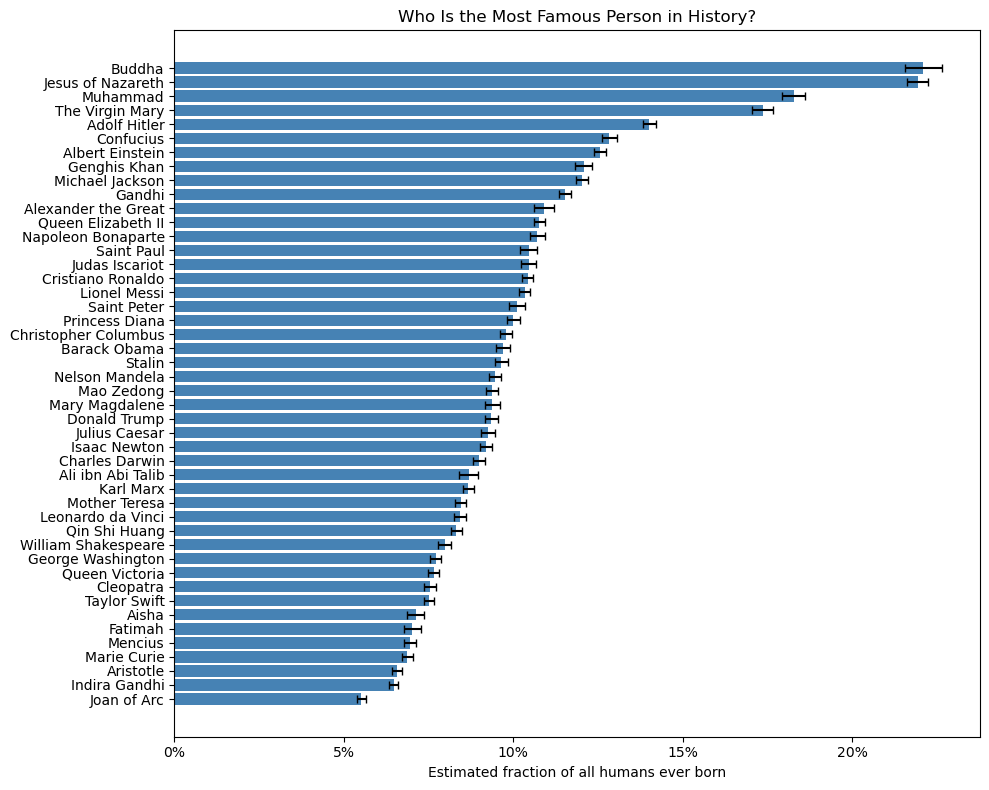

In [20]:
# Bar chart
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

names = [CANDIDATES[i] for i in ranking]
fracs = [fame_fractions[i] for i in ranking]
ses = [fame_ses[i] for i in ranking]

bars = ax.barh(range(len(names)), fracs, xerr=ses, capsize=3, color='steelblue')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('Estimated fraction of all humans ever born')
ax.set_title('Who Is the Most Famous Person in History?')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

In [23]:
# ── Fame among currently living people ──
# P(knows candidate | alive) = Σ_h (N_h^alive × μ_h^alive) / Σ_h (N_h^alive)
# where μ_h^alive = mean prob among alive draws in bin h

# 1. Count alive people per bin from the full filtered population
alive_per_bin = np.zeros(n_bins)
for idx, (dy, b) in enumerate(zip(reweight_data["filtered_death_years"],
                                   reweight_data["filtered_bin_indices"])):
    if dy >= 2026 and b is not None:
        alive_per_bin[b] += 1

n_alive_total = int(alive_per_bin.sum())
print(f"Alive people in filtered set: {n_alive_total:,} / {n_filtered:,} "
      f"({n_alive_total/n_filtered:.1%})")

# 2. Group alive draws by bin
alive_bin_results = defaultdict(list)
for person, full_probs, raw_text, bin_idx in results:
    if person.age_at_death == "alive":
        vec = np.zeros(n_candidates)
        for cand_idx, prob in full_probs.items():
            vec[cand_idx] = prob
        alive_bin_results[bin_idx].append(vec)

# 3. Compute stratified estimate among alive people
alive_bin_means = np.zeros((n_bins, n_candidates))
alive_bin_vars = np.zeros((n_bins, n_candidates))
alive_bin_n = np.zeros(n_bins, dtype=int)

for b in range(n_bins):
    obs = alive_bin_results.get(b, [])
    alive_bin_n[b] = len(obs)
    if len(obs) >= 1:
        obs = np.array(obs)
        alive_bin_means[b] = obs.mean(axis=0)
        if len(obs) >= 2:
            alive_bin_vars[b] = obs.var(axis=0, ddof=1)

# Weighted average: weight each bin by its alive population
N_alive = alive_per_bin  # alive population per bin
total_alive = N_alive.sum()

alive_fame = np.zeros(n_candidates)
for b in range(n_bins):
    if alive_bin_n[b] > 0:
        alive_fame += N_alive[b] * alive_bin_means[b]
alive_fame /= total_alive

# SE among alive
alive_strat_var = np.zeros(n_candidates)
for b in range(n_bins):
    if alive_bin_n[b] >= 2:
        alive_strat_var += N_alive[b]**2 * alive_bin_vars[b] / alive_bin_n[b]
alive_ses = np.sqrt(alive_strat_var) / total_alive

# Sort and display
alive_ranking = sorted(range(n_candidates), key=lambda i: alive_fame[i], reverse=True)

print(f"\nEstimated fraction of currently living people who have heard of...\n")
print(f"{'Rank':<5} {'Name':<25} {'% alive':>8} {'±1 SE':>7} {'% all':>7}")
print("-" * 55)
for rank, i in enumerate(alive_ranking, 1):
    print(f"{rank:<5} {CANDIDATES[i]:<25} {alive_fame[i]:>7.1%} {alive_ses[i]:>6.2%} {fame_fractions[i]:>6.1%}")

# Count alive draws per bin for diagnostics
bins_with_alive = sum(1 for b in range(n_bins) if alive_bin_n[b] > 0)
total_alive_draws = sum(alive_bin_n)
print(f"\nAlive draws: {total_alive_draws} across {bins_with_alive} bins")

Alive people in filtered set: 11,923 / 45,808 (26.0%)

Estimated fraction of currently living people who have heard of...

Rank  Name                       % alive   ±1 SE   % all
-------------------------------------------------------
1     Jesus of Nazareth           86.4%  0.81%  21.9%
2     Michael Jackson             81.6%  0.97%  12.0%
3     Adolf Hitler                81.0%  1.05%  14.0%
4     Cristiano Ronaldo           79.3%  0.85%  10.4%
5     Lionel Messi                79.3%  0.84%  10.3%
6     Albert Einstein             79.0%  1.00%  12.6%
7     Muhammad                    74.6%  1.14%  18.3%
8     Donald Trump                72.7%  1.08%   9.4%
9     Barack Obama                72.4%  1.17%   9.7%
10    Queen Elizabeth II          69.5%  1.08%  10.8%
11    Gandhi                      67.5%  1.03%  11.5%
12    Princess Diana              67.5%  1.21%  10.0%
13    Buddha                      65.1%  1.00%  22.1%
14    Nelson Mandela              64.2%  1.22%   9.5%
15    Th

## 5. Inspect individual responses

Full reasoning text is preserved — spot-check to see if the LLM is thinking sensibly.

In [23]:
# Show a few examples with full reasoning and labeled probabilities
for person, full_probs, raw_text, bin_idx in results[-50:]:
    print('=' * 70)
    key = final_keys[bin_idx]
    print(f"{format_person_light(person)}  [bin={key}]")
    print('-' * 70)
    # Print reasoning (everything before the JSON)
    json_start = raw_text.find('{')
    if json_start > 0:
        print(raw_text[:json_start].strip())
    print()
    # Print probabilities with candidate names
    for cand_idx, prob in sorted(full_probs.items()):
        if prob > 0:
            print(f"  {CANDIDATES[cand_idx]:<35s} {prob:.0%}")
    print()

Era: Holocene
Birth year: 327 BC
Age at death: 58
Sex: M
Country: India
Subregion: Karnātaka  [bin=('pre-0', '_merged')]
----------------------------------------------------------------------
This man was born in 327 BC in what is now Karnataka (southern India) and lived to about 269 BC. For a randomly sampled male in that place/time, the base case is a mostly rural agrarian life with limited or no literacy; “knowing” someone usually means via oral tradition, religious communities, travelers/merchants, court/administrative networks, or (for a minority) formal education.

Key context for diffusion of fame in his lifetime:
- **Buddhism** was already established and spreading across India by the 4th–3rd centuries BC, with monastic networks and itinerant teachers; knowledge of the Buddha as a revered teacher could reach even non-elites, though penetration in far-southern regions may have been uneven compared to the Gangetic heartland.
- **Greek/Macedonian** events (Alexander) could be know

In [22]:
# ── Save all variables needed for reweighting / sensitivity analysis ──
# This lets you recompute aggregations under different population assumptions
# (e.g., higher pre-modern populations) without re-running LLM queries.

import dill

reweight_data = {
    # Per-draw data: list of (bin_index, prob_vector) for each LLM call
    "draws": [
        (bin_idx, {cand_idx: prob for cand_idx, prob in full_probs.items()})
        for person, full_probs, raw_text, bin_idx in results
    ],
    
    # Bin structure: bin_index -> (bin_key, population_size)
    "bins": {
        b: {"key": final_keys[b], "pop": int(final_sizes[b])}
        for b in range(len(final_keys))
    },
    
    # Per-person death years (filtered population), with bin assignments
    # Needed to recompute fame ceilings
    "filtered_death_years": filtered_death_years.tolist(),
    
    # Population counts
    "n_total": n_total,
    "n_filtered": n_filtered,
    
    # Candidate metadata
    "candidates": CANDIDATES[:],
    "fame_start": dict(FAME_START),
    
    # Per-person birth years in filtered set (for reweighting by era)
    "filtered_birth_years": [p.birth_year for p in filtered],
    
    # Bin assignment for each person in filtered (so you can reweight bin populations)
    "filtered_bin_indices": [None] * n_filtered,
}

# Fill in bin assignments for filtered people
for b, key in enumerate(final_keys):
    for idx in final_bins[key]:
        reweight_data["filtered_bin_indices"][idx] = b

REWEIGHT_FILE = 'famous_person_reweight_800s.pkl'
with open(REWEIGHT_FILE, 'wb') as f:
    dill.dump(reweight_data, f)

print(f"Saved reweighting data to {REWEIGHT_FILE}")
print(f"  {len(reweight_data['draws'])} draws across {len(reweight_data['bins'])} bins")
print(f"  {len(reweight_data['candidates'])} candidates")
print(f"  {n_filtered} filtered people with birth years and bin assignments")

Saved reweighting data to famous_person_reweight_800s.pkl
  819 draws across 74 bins
  46 candidates
  45808 filtered people with birth years and bin assignments
